In [2]:
import pandas as pd
import numpy as np

In [3]:
   # Common encodings used in pandas #
# Encoding	 -->     Used When
# utf-8	Most -->    modern datasets
# cp1252	 -->   Windows / Excel CSV files
# latin1	 -->  European text
# utf-16	 -->  Some Excel exports

df = pd.read_csv('airquality_data.csv', encoding='cp1252')

C:\Users\admin\AppData\Local\Temp\ipykernel_8084\4005560202.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airquality_data.csv', encoding='cp1252')


In [4]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,01-02-1990
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,01-02-1990
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,01-02-1990
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,01-03-1990
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,01-03-1990


In [5]:
df.shape

(435742, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [7]:
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

### Data Cleaning

In [8]:
# Change data type from float64 to float32 for Space Complexity
df['so2'] = df['so2'].astype('float32')
df['no2'] = df['no2'].astype('float32')
df['rspm'] = df['rspm'].astype('float32')
df['spm'] = df['spm'].astype('float32')
df['date'] = df['date'].astype('string')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float32
 7   no2                          419509 non-null  float32
 8   rspm                         395520 non-null  float32
 9   spm                          198355 non-null  float32
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  string 
dtyp

In [9]:
df['date'].head(120)

0      01-02-1990
1      01-02-1990
2      01-02-1990
3      01-03-1990
4      01-03-1990
          ...    
115    01-06-1992
116    01-06-1992
117    01-06-1992
118    01-07-1992
119    01-07-1992
Name: date, Length: 120, dtype: string

In [10]:
# Converion of Date Format yyyy-mm-dd to dd-mm-yyyy based on requirement
df['date'] = pd.to_datetime(df['date']).dt.strftime('%d-%m-%Y')
df['date'].head(120)

ValueError: time data "16-01-2004" doesn't match format "%m-%d-%Y", at position 157. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [11]:
# Check how many duplicate rows exist
df.duplicated().sum()

674

In [12]:
# View which rows are duplicates
df[df.duplicated()]

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
236,95.0,September - M091994,Andhra Pradesh,Hyderabad,Andhra Pradesh Pollution Control Board,NaN,1.900000,4.500000,NaN,NaN,NaN,NaN,01-09-1994
237,202.0,September - M091994,Andhra Pradesh,Hyderabad,Andhra Pradesh Pollution Control Board,NaN,0.900000,2.600000,NaN,NaN,NaN,NaN,01-09-1994
238,203.0,September - M091994,Andhra Pradesh,Hyderabad,Andhra Pradesh Pollution Control Board,NaN,1.300000,6.700000,NaN,NaN,NaN,NaN,01-09-1994
13322,582.0,03-01-2011,Andhra Pradesh,Chittoor,Andhra Pradesh State Pollution Control Board,Sensitive Area,4.000000,9.000000,40.0,101.0,"GNC Toll Gate Tirumala , Chittoor Dist.",NaN,03-01-2011
13324,582.0,03-03-2011,Andhra Pradesh,Chittoor,Andhra Pradesh State Pollution Control Board,Sensitive Area,4.000000,9.000000,35.0,101.0,"GNC Toll Gate Tirumala , Chittoor Dist.",NaN,03-03-2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413835,8,September - M091994,West Bengal,Howrah,West Bengal Pollution Control Board,Industrial Area,57.599998,158.600006,NaN,276.0,NaN,NaN,01-09-1994
413836,9,September - M091994,West Bengal,Howrah,West Bengal Pollution Control Board,Industrial Area,32.500000,156.100006,NaN,140.0,NaN,NaN,01-09-1994
413837,10,September - M091994,West Bengal,Howrah,West Bengal Pollution Control Board,Industrial Area,63.799999,214.000000,NaN,234.0,NaN,NaN,01-09-1994
413838,15,September - M091994,West Bengal,Haldia,CMEC,Industrial Area,39.799999,63.500000,NaN,126.0,NaN,NaN,01-09-1994


In [14]:
# Drop Duplicate Entries
df=df.drop_duplicates()


In [15]:
# Now check after drop how many duplicate rows exist
df.duplicated().sum()

0

In [16]:
df.isna().sum()

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149466
type                             5357
so2                             34632
no2                             16222
rspm                            40035
spm                            236908
location_monitoring_station     27303
pm2_5                          425754
date                                7
dtype: int64

In [17]:
len(df)

435068

In [19]:
percent_missing = df.isnull().sum() * 100 / len(df)

In [27]:
percent_missing

stn_code                       33.115973
sampling_date                   0.000690
state                           0.000000
location                        0.000690
agency                         34.354630
type                            1.231302
so2                             7.960135
no2                             3.728613
rspm                            9.202010
spm                            54.453097
location_monitoring_station     6.275571
pm2_5                          97.859185
date                            0.001609
dtype: float64

In [20]:
percent_missing.sort_values(ascending=False)

pm2_5                          97.859185
spm                            54.453097
agency                         34.354630
stn_code                       33.115973
rspm                            9.202010
so2                             7.960135
location_monitoring_station     6.275571
no2                             3.728613
type                            1.231302
date                            0.001609
sampling_date                   0.000690
location                        0.000690
state                           0.000000
dtype: float64

In [22]:
df=df.drop(['stn_code', 'agency','sampling_date','location_monitoring_station','pm2_5'], axis = 1)

In [23]:
df.head()

,state,location,type,so2,no2,rspm,spm,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,01-02-1990
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,NaN,NaN,01-02-1990
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,01-02-1990
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,01-03-1990
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,NaN,NaN,01-03-1990


In [24]:
df.columns

Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'date'], dtype='object')

In [28]:
col_var = ['state', 'location', 'type','date']
col_num = ['so2','no2','rspm','spm']

In [25]:
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'string':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [26]:
df.isna().sum()

state       0
location    0
type        0
so2         0
no2         0
rspm        0
spm         0
date        0
dtype: int64

In [27]:
df

,state,location,type,so2,no2,rspm,spm,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.800000,17.400000,108.871712,220.774796,01-02-1990
1,Andhra Pradesh,Hyderabad,Industrial Area,3.100000,7.000000,108.871712,220.774796,01-02-1990
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.200000,28.500000,108.871712,220.774796,01-02-1990
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.300000,14.700000,108.871712,220.774796,01-03-1990
4,Andhra Pradesh,Hyderabad,Industrial Area,4.700000,7.500000,108.871712,220.774796,01-03-1990
...,...,...,...,...,...,...,...,...
435737,West Bengal,ULUBERIA,RIRUO,22.000000,50.000000,143.000000,220.774796,24-12-2015
435738,West Bengal,ULUBERIA,RIRUO,20.000000,46.000000,171.000000,220.774796,29-12-2015
435739,andaman-and-nicobar-islands,Guwahati,"Residential, Rural and other Areas",10.830467,25.823299,108.871712,220.774796,19-03-2015
435740,Lakshadweep,Guwahati,"Residential, Rural and other Areas",10.830467,25.823299,108.871712,220.774796,19-03-2015



# Data integration

In [28]:
subSet1 = df[['state', 'type']]
subSet2 = df[['state','location']]

In [29]:
subSet1.head()

,state,type
0,Andhra Pradesh,"Residential, Rural and other Areas"
1,Andhra Pradesh,Industrial Area
2,Andhra Pradesh,"Residential, Rural and other Areas"
3,Andhra Pradesh,"Residential, Rural and other Areas"
4,Andhra Pradesh,Industrial Area


In [30]:
subSet2.head()

,state,location
0,Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Hyderabad
2,Andhra Pradesh,Hyderabad
3,Andhra Pradesh,Hyderabad
4,Andhra Pradesh,Hyderabad


In [31]:
subSet1 = subSet1.drop_duplicates()
subSet2 = subSet2.drop_duplicates()

In [32]:
# Merge can also apply
s1=pd.merge(subSet1,subSet2,on='state')
s1

,state,type,location
0,Andhra Pradesh,"Residential, Rural and other Areas",Hyderabad
1,Andhra Pradesh,"Residential, Rural and other Areas",Vishakhapatnam
2,Andhra Pradesh,"Residential, Rural and other Areas",Visakhapatnam
3,Andhra Pradesh,"Residential, Rural and other Areas",Tirupati
4,Andhra Pradesh,"Residential, Rural and other Areas",Vijayawada
...,...,...,...
1905,West Bengal,RIRUO,SILIGURI
1906,West Bengal,RIRUO,ULUBERIA
1907,andaman-and-nicobar-islands,"Residential, Rural and other Areas",Guwahati
1908,Lakshadweep,"Residential, Rural and other Areas",Guwahati


In [33]:
concatenated_df = pd.concat([subSet1, subSet2], axis=1)

In [34]:
concatenated_df

,state,type,state,location
0,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Industrial Area,NaN,NaN
1794,Andhra Pradesh,Sensitive Area,NaN,NaN
1944,Andhra Pradesh,Industrial Areas,NaN,NaN
2221,Andhra Pradesh,Residential and others,NaN,NaN
...,...,...,...,...
435011,NaN,NaN,West Bengal,HALDIA
435115,NaN,NaN,West Bengal,Kalyani
435427,NaN,NaN,West Bengal,MALDAH
435531,NaN,NaN,West Bengal,SILIGURI


### Error Correcting

In [35]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    return column[~outlier_mask]

In [36]:
df.columns

Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'date'], dtype='object')

In [38]:
# Remove outliers for each column using a loop
col_name = ['so2', 'no2', 'rspm', 'spm']
for col in col_name:
    df[col] = remove_outliers(df[col])

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

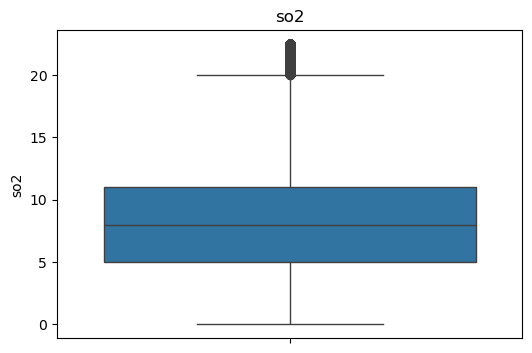

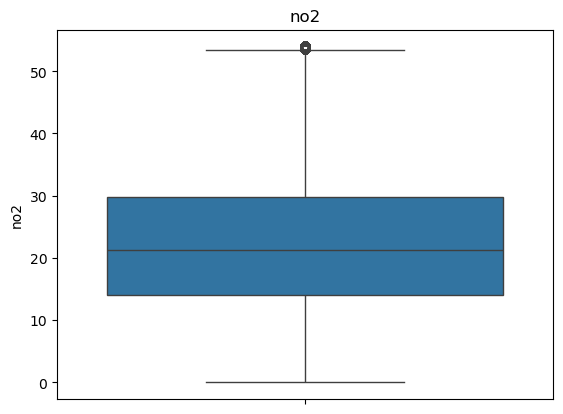

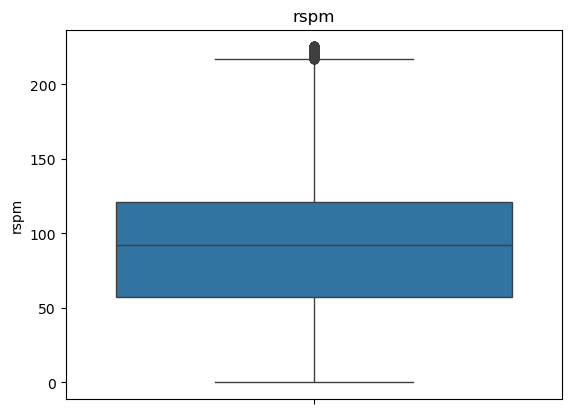

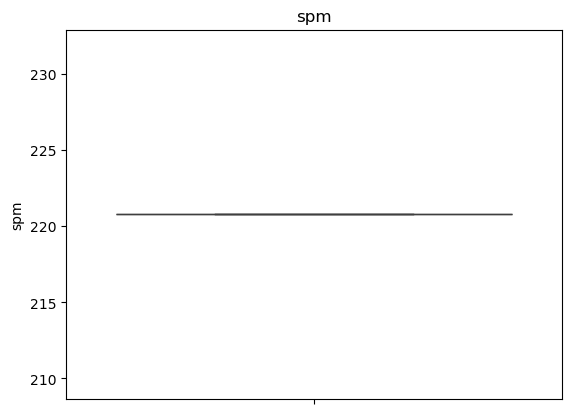

In [40]:
plt.figure(figsize=(6,4))  # Adjust the figure size if needed

for col in col_name:
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()

## Data Transform

In [144]:
# LabelEncoder is useful for convert categorical values into Numerical values
from sklearn.preprocessing import LabelEncoder

col_label= ['state','location','type']
# Initialize LabelEncoder

encoder = LabelEncoder()
# Iterate over columns
for col in df.columns:
        # Fit and transform the column
        df[col] = encoder.fit_transform(df[col])

In [145]:
df

,state,location,type,so2,no2,rspm,spm,date,state_encoded
0,0,114,6,446,1489,2030,2990,32,0
1,0,114,1,197,250,2030,2990,32,0
2,0,114,6,790,3096,2030,2990,32,0
3,0,114,6,823,1144,2030,2990,60,0
4,0,114,1,427,301,2030,2990,60,0
...,...,...,...,...,...,...,...,...,...
435737,35,282,3,2888,5307,2534,2990,4057,35
435738,35,282,3,2809,5113,3098,2990,4832,35
435739,36,100,6,1638,2696,2030,2990,3157,36
435740,17,100,6,1638,2696,2030,2990,3157,17


In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['state'])

le.classes_

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadra & Nagar Haveli',
       'Daman & Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana',
       'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka',
       'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra',
       'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha',
       'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
       'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
       'Uttaranchal', 'West Bengal', 'andaman-and-nicobar-islands'],
      dtype=object)

In [42]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)


{'Andhra Pradesh': 0, 'Arunachal Pradesh': 1, 'Assam': 2, 'Bihar': 3, 'Chandigarh': 4, 'Chhattisgarh': 5, 'Dadra & Nagar Haveli': 6, 'Daman & Diu': 7, 'Delhi': 8, 'Goa': 9, 'Gujarat': 10, 'Haryana': 11, 'Himachal Pradesh': 12, 'Jammu & Kashmir': 13, 'Jharkhand': 14, 'Karnataka': 15, 'Kerala': 16, 'Lakshadweep': 17, 'Madhya Pradesh': 18, 'Maharashtra': 19, 'Manipur': 20, 'Meghalaya': 21, 'Mizoram': 22, 'Nagaland': 23, 'Odisha': 24, 'Puducherry': 25, 'Punjab': 26, 'Rajasthan': 27, 'Sikkim': 28, 'Tamil Nadu': 29, 'Telangana': 30, 'Tripura': 31, 'Uttar Pradesh': 32, 'Uttarakhand': 33, 'Uttaranchal': 34, 'West Bengal': 35, 'andaman-and-nicobar-islands': 36}


In [43]:
df['state_encoded'] = le.fit_transform(df['state'])

dict(zip(le.classes_, le.transform(le.classes_)))


{'Andhra Pradesh': 0,
 'Arunachal Pradesh': 1,
 'Assam': 2,
 'Bihar': 3,
 'Chandigarh': 4,
 'Chhattisgarh': 5,
 'Dadra & Nagar Haveli': 6,
 'Daman & Diu': 7,
 'Delhi': 8,
 'Goa': 9,
 'Gujarat': 10,
 'Haryana': 11,
 'Himachal Pradesh': 12,
 'Jammu & Kashmir': 13,
 'Jharkhand': 14,
 'Karnataka': 15,
 'Kerala': 16,
 'Lakshadweep': 17,
 'Madhya Pradesh': 18,
 'Maharashtra': 19,
 'Manipur': 20,
 'Meghalaya': 21,
 'Mizoram': 22,
 'Nagaland': 23,
 'Odisha': 24,
 'Puducherry': 25,
 'Punjab': 26,
 'Rajasthan': 27,
 'Sikkim': 28,
 'Tamil Nadu': 29,
 'Telangana': 30,
 'Tripura': 31,
 'Uttar Pradesh': 32,
 'Uttarakhand': 33,
 'Uttaranchal': 34,
 'West Bengal': 35,
 'andaman-and-nicobar-islands': 36}